<a href="https://colab.research.google.com/github/Sageh9/MSSP607/blob/main/week8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipython-input-951579.py:10: DtypeWarning:

Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.



Columns: ['ID', 'CustomerKey', 'GeographyKey', 'City', 'CountryRegionCode', 'EnglishCountryRegionName', 'CustomerAlternateKey', 'Title', 'FirstName', 'MiddleName', 'LastName', 'NameStyle', 'BirthDate', 'MaritalStatus', 'Suffix', 'Gender', 'EmailAddress', 'YearlyIncome', 'TotalChildren', 'NumberChildrenAtHome', 'EnglishEducation', 'SpanishEducation', 'FrenchEducation', 'EnglishOccupation', 'SpanishOccupation', 'FrenchOccupation', 'HouseOwnerFlag', 'NumberCarsOwned', 'AddressLine1', 'AddressLine2', 'Phone', 'DateFirstPurchase', 'CommuteDistance', 'ProductKey', 'EnglishProductName', 'OrderDateKey', 'DueDateKey', 'ShipDateKey', 'CustomerKey.1', 'PromotionKey', 'CurrencyKey', 'SalesTerritoryKey', 'SalesOrderNumber', 'SalesOrderLineNumber', 'RevisionNumber', 'OrderQuantity', 'UnitPrice', 'ExtendedAmount', 'UnitPriceDiscountPct', 'DiscountAmount', 'ProductStandardCost', 'TotalProductCost', 'SalesAmount', 'TaxAmt', 'Freight', 'CarrierTrackingNumber', 'CustomerPONumber', 'OrderDate', 'DueDate',

,ProductName,total_sales,orders,avg_sales
10,312,1.205877e+06,337,3578.2700
8,310,1.202299e+06,336,3578.2700
11,313,1.080638e+06,302,3578.2700
12,314,1.055590e+06,295,3578.2700
9,311,1.005494e+06,281,3578.2700
54,361,9.799607e+05,427,2294.9900
46,353,9.790358e+05,422,2319.9900
56,363,9.616008e+05,419,2294.9900
52,359,9.547158e+05,416,2294.9900
50,357,9.303160e+05,401,2319.9900


Product with highest total sales: 312
[{'ProductName': '312', 'total_sales': 1205876.99, 'orders': 337, 'avg_sales': 3578.27}]


,ds,y
0,2010-12-01,43421.0364
1,2011-01-01,469823.9148
2,2011-02-01,466334.9030
3,2011-03-01,485198.6594
4,2011-04-01,502073.8458


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1872: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



,ds,yhat,yhat_lower,yhat_upper
88,2018-03-31,2.673996e+06,2.260145e+06,3.062076e+06
89,2018-04-30,2.786705e+06,2.388302e+06,3.200130e+06
90,2018-05-31,2.917128e+06,2.529920e+06,3.332280e+06
91,2018-06-30,2.764625e+06,2.392787e+06,3.166403e+06
92,2018-07-31,2.792061e+06,2.391844e+06,3.206531e+06
93,2018-08-31,2.849753e+06,2.450311e+06,3.296705e+06
94,2018-09-30,3.069002e+06,2.671057e+06,3.493798e+06
95,2018-10-31,3.021574e+06,2.624868e+06,3.400254e+06
96,2018-11-30,2.755218e+06,2.317355e+06,3.150237e+06
97,2018-12-31,2.884701e+06,2.493911e+06,3.290534e+06


Files saved: sales_forecast_5y.csv and product_summary_stats.csv
Product 312 has insufficient data points (13).


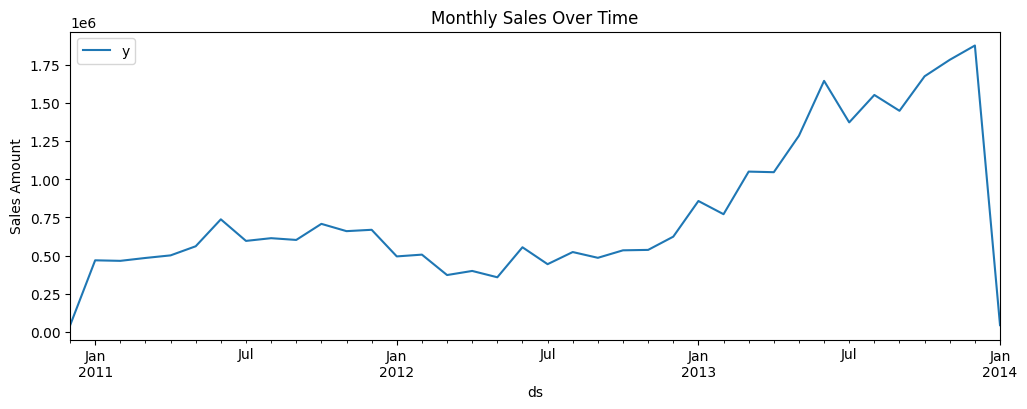

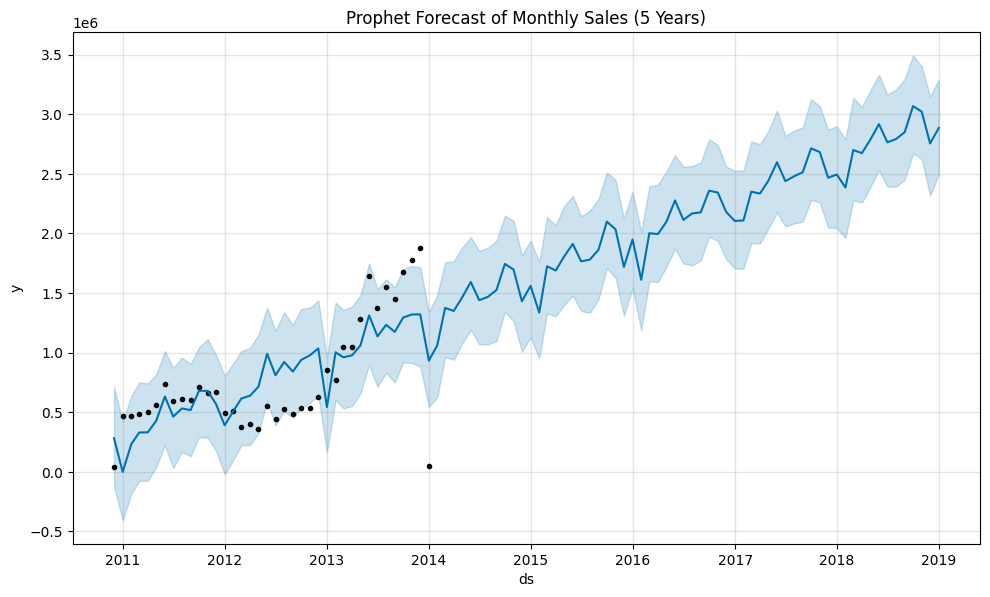

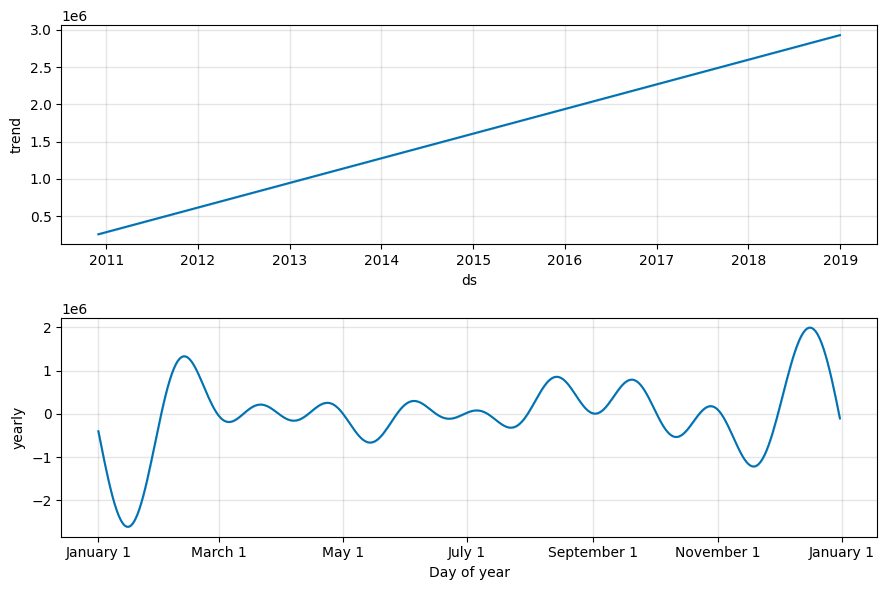

In [4]:
!pip install prophet cmdstanpy --quiet

import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

# === Load data (Method B: upload CSV to Colab) ===
# After uploading your file via the Files panel, use the exact filename below.
# === Load data (Method B) ===
df = pd.read_csv('InternetSales.csv', encoding='latin1', parse_dates=['OrderDate'])
df.head()


# === Basic cleaning ===
print("Columns:", df.columns.tolist())
df = df.dropna(subset=['OrderDate'])

if 'SalesAmount' in df.columns:
    df['SalesAmount'] = pd.to_numeric(df['SalesAmount'], errors='coerce')
elif 'LineTotal' in df.columns:
    df['SalesAmount'] = pd.to_numeric(df['LineTotal'], errors='coerce')
else:
    raise ValueError("No SalesAmount or LineTotal column found. Please check column names.")

if 'ProductName' not in df.columns and 'ProductKey' in df.columns:
    df['ProductName'] = df['ProductKey'].astype(str)

# === Summary statistics (find top-selling product) ===
prod_stats = (
    df.groupby('ProductName')
      .agg(total_sales=('SalesAmount', 'sum'),
           orders=('SalesAmount', 'count'),
           avg_sales=('SalesAmount', 'mean'))
      .reset_index()
      .sort_values('total_sales', ascending=False)
)

print("Top 20 products by total sales:")
display(prod_stats.head(20))

top_product = prod_stats.iloc[0]
print(f"Product with highest total sales: {top_product['ProductName']}")
print(prod_stats.head(1).to_dict(orient='records'))

# === Prepare monthly time series ===
df['OrderMonth'] = df['OrderDate'].dt.to_period('M').dt.to_timestamp()
ts = (
    df.groupby('OrderMonth')
      .agg(monthly_sales=('SalesAmount', 'sum'))
      .reset_index()
      .rename(columns={'OrderMonth': 'ds', 'monthly_sales': 'y'})
)

display(ts.head())
ts.set_index('ds').plot(y='y', figsize=(12,4), title='Monthly Sales Over Time')
plt.ylabel('Sales Amount')

# === Prophet forecast for 5 years (60 months) ===
m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m.fit(ts)

future = m.make_future_dataframe(periods=60, freq='M')
forecast = m.predict(future)

display(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10))

# === Plot results ===
fig1 = m.plot(forecast)
plt.title('Prophet Forecast of Monthly Sales (5 Years)')
fig2 = m.plot_components(forecast)

fig_pf = px.line(forecast, x='ds', y='yhat', title='Forecast (yhat) - Interactive')
fig_pf.add_scatter(x=ts['ds'], y=ts['y'], mode='markers', name='history')
fig_pf.show()

# === Save results ===
forecast[['ds','yhat','yhat_lower','yhat_upper']].to_csv('sales_forecast_5y.csv', index=False)
prod_stats.to_csv('product_summary_stats.csv', index=False)
print("Files saved: sales_forecast_5y.csv and product_summary_stats.csv")

# === Optional: Forecast for top single product ===
prod_name = prod_stats.iloc[0]['ProductName']
df_prod = df[df['ProductName'] == prod_name].copy()
df_prod['OrderMonth'] = df_prod['OrderDate'].dt.to_period('M').dt.to_timestamp()
ts_prod = (
    df_prod.groupby('OrderMonth')
           .agg(y=('SalesAmount','sum'))
           .reset_index()
           .rename(columns={'OrderMonth':'ds'})
)

if len(ts_prod) >= 24:
    m2 = Prophet(yearly_seasonality=True)
    m2.fit(ts_prod)
    fut2 = m2.make_future_dataframe(periods=60, freq='M')
    fc2 = m2.predict(fut2)
    m2.plot(fc2)
    plt.title(f'Forecast for product: {prod_name}')
    fc2[['ds','yhat']].to_csv(f'forecast_{prod_name[:20]}.csv', index=False)
else:
    print(f"Product {prod_name} has insufficient data points ({len(ts_prod)}).")
